# EDA — Brazilian Federal Highway Accidents (2017–2023)

This notebook prepares the dataset for severity classification.
The work follows a single pass: load, clean, single-variable analysis, multi-variable analysis, feature engineering and finishes with the cleaned dataframe ready for modelling.

**Research questions**

1. How well do standard multiclass classification models predict traffic accident severity?
2. How does handling class imbalance affect the performance of these models, and how do the main methods of class imbalance handling compare?
3. Which features are most important in predicting traffic accident severity?

---
## 1 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

# --- Plot theme ---
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize':   (10, 5),
    'figure.dpi':       100,
    'axes.titleweight': 'bold',
    'axes.titlesize':   13,
    'axes.titlepad':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':        11,
})

# --- Palette ---
PALETTE = {
    'primary':  '#2E86AB',   # blue   — neutral / counts
    'accent':   '#E07A5F',   # coral  — highlight
    'danger':   '#C73E1D',   # red    — fatal / severe
    'warn':     '#F2A65A',   # amber  — injured
    'ok':       '#6BAA75',   # green  — without victims
    'muted':    '#9CA0A8',   # grey   — context
}
SEVERITY_COLORS = [PALETTE['ok'], PALETTE['warn'], PALETTE['danger']]

In [2]:
df = pd.read_csv('accidents_2017_to_2023_english.csv')
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded 463,152 rows × 27 columns


---
## 2 · First look

Shape, types, and head

In [3]:
print("Shape :", df.shape, "\n")
print("Dtypes:")
print(df.dtypes.to_string())
print()
df.head()

Shape : (463152, 27) 

Dtypes:
inverse_data           object
week_day               object
hour                   object
state                  object
road_id               float64
km                     object
city                   object
cause_of_accident      object
type_of_accident       object
victims_condition      object
weather_timestamp      object
road_direction         object
wheather_condition     object
road_type              object
road_delineation       object
people                  int64
deaths                  int64
slightly_injured        int64
severely_injured        int64
uninjured               int64
ignored                 int64
total_injured           int64
vehicles_involved       int64
latitude              float64
longitude             float64
regional               object
police_station         object



,inverse_data,week_day,hour,state,road_id,km,city,cause_of_accident,type_of_accident,victims_condition,weather_timestamp,road_direction,wheather_condition,road_type,road_delineation,people,deaths,slightly_injured,severely_injured,uninjured,ignored,total_injured,vehicles_involved,latitude,longitude,regional,police_station
0,2017-01-01,sunday,01:45:00,RS,116.000,"34,9",VACARIA,Mechanical loss/defect of vehicle,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,6,0,4,0,2,0,4,2,-28.507,-50.941,SPRF-RS,DEL05-RS
1,2017-01-01,sunday,01:00:00,PR,376.000,636,TIJUCAS DO SUL,Incompatible velocity,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,1,0,0,1,0,0,2,-25.754,-49.127,SPRF-PR,DEL01-PR
2,2017-01-01,sunday,04:40:00,BA,101.000,65,ENTRE RIOS,Driver was sleeping,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,5,1,1,1,2,0,2,2,-11.962,-38.095,SPRF-BA,DEL01-BA
3,2017-01-01,sunday,06:30:00,PA,316.000,"72,5",CASTANHAL,Driver's lack of attention to conveyance,Side impact collision,With dead victims,Sunrise,Decreasing,Clear sky,Simple,Straight,4,1,0,0,3,0,0,3,-1.290,-47.835,SPRF-PA,DEL01-PA
4,2017-01-01,sunday,09:00:00,GO,20.000,"220,5",POSSE,Road's defect,Collision with fixed object,With injured victims,Day,Decreasing,Clear sky,Simple,Temporary Detour,3,0,2,1,0,0,3,1,-14.142,-46.323,SPRF-DF,DEL02-DF


---
## 3 · Rename columns

The original names are inconsistent (mixed case, typos like `wheather_condition`).

In [4]:
df = df.rename(columns={
    'inverse_data':       'Date',
    'week_day':           'Day',
    'hour':               'Hour',
    'state':              'State',
    'road_id':            'Road_ID',
    'km':                 'Road_Km',
    'city':               'City',
    'cause_of_accident':  'Accident_Cause',
    'type_of_accident':   'Accident_Type',
    'victims_condition':  'Victims_Condition',
    'weather_timestamp':  'Day_Phase',
    'road_direction':     'Km_Direction',
    'wheather_condition': 'Weather_Condition',
    'road_type':          'Road_Type',
    'road_delineation':   'Road_Delineation',
    'people':             'People',
    'deaths':             'Deaths',
    'slightly_injured':   'Slightly_Injured',
    'severely_injured':   'Severely_Injured',
    'uninjured':          'Uninjured',
    'ignored':            'Ignored',
    'total_injured':      'Total_Injured',
    'vehicles_involved':  'Vehicles_Involved',
    'latitude':           'Latitude',
    'longitude':          'Longitude',
    'regional':           'Regional',
    'police_station':     'Police_Station',
})

df.head(3)

,Date,Day,Hour,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station
0,2017-01-01,sunday,01:45:00,RS,116.000,"34,9",VACARIA,Mechanical loss/defect of vehicle,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,6,0,4,0,2,0,4,2,-28.507,-50.941,SPRF-RS,DEL05-RS
1,2017-01-01,sunday,01:00:00,PR,376.000,636,TIJUCAS DO SUL,Incompatible velocity,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,1,0,0,1,0,0,2,-25.754,-49.127,SPRF-PR,DEL01-PR
2,2017-01-01,sunday,04:40:00,BA,101.000,65,ENTRE RIOS,Driver was sleeping,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,5,1,1,1,2,0,2,2,-11.962,-38.095,SPRF-BA,DEL01-BA


---
## 4 · Datetime & numeric conversions

Two cleanups, done together:

* `Date` + `Hour` => a single `Datetime` column (the originals are dropped).
* `Road_Km` uses European decimals — replace the comma so pandas sees a number.

In [5]:
# Combine Date + Hour, then drop the originals
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Hour'].astype(str))
df = df.drop(columns=['Date', 'Hour'])

# Move Datetime to the front for readability
df = df[['Datetime'] + [c for c in df.columns if c != 'Datetime']]

# Convert Road_Km (handling European decimal format)
df['Road_Km'] = pd.to_numeric(df['Road_Km'].str.replace(',', '.'), errors='coerce')

print(f"Datetime range: {df['Datetime'].min()}  =>  {df['Datetime'].max()}")
print(f"Road_Km dtype : {df['Road_Km'].dtype}")

Datetime range: 2017-01-01 00:00:00  =>  2023-08-31 23:59:00
Road_Km dtype : float64


---
## 5 · Missing values

Three columns hold all of the missingness. Each gets a treatment that fits its meaning:

| Column | Strategy | Rationale |
|---|---|---|
| `Regional` | drop the rows | very few rows, can't be filled |
| `Police_Station` | fill with `"UNKNOWN"` | usable categorical placeholder |
| `Road_ID` / `Road_Km` | sentinel + flag column | the *fact that road info is missing* is itself a feature |

In [6]:
print("Nulls before treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())

Nulls before treatment:
Road_ID            990
Road_Km            990
Regional            10
Police_Station    1310


In [7]:
# 1) Drop rows missing Regional (very few)
df = df.dropna(subset=['Regional'])

# 2) Police_Station — fill with placeholder
df['Police_Station'] = df['Police_Station'].fillna('UNKNOWN')

# 3) Road_ID / Road_Km — flag + sentinel fill
df['Missing_Road_Data'] = df['Road_ID'].isna()
df['Road_ID']  = df['Road_ID'].fillna('NO_ROAD')
df['Road_Km']  = df['Road_Km'].fillna(-1)

remaining = df.isnull().sum().sum()
print(f"Remaining nulls: {remaining}")

Remaining nulls: 0


---
## 6 · Duplicate rows

Per supervisor feedback, exact duplicates will be dropped.

In [8]:
dups = df.duplicated().sum()
print(f"Exact duplicate rows: {dups}")

if dups:
    display(df[df.duplicated(keep=False)])

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDropped {before - len(df)} rows  =>  {len(df):,} remaining")

Exact duplicate rows: 9


,Datetime,Day,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station,Missing_Road_Data
19243,2017-10-20 14:25:00,friday,SC,282.000,483.900,FAXINAL DOS GUEDES,Disrespect of safe distance from the next car,Rear-end collision,Without victims,Day,Increasing,Sunny,Simple,Not Reported,2,0,0,0,2,0,0,2,-26.857,-52.246,SPRF-SC,DEL07-SC,False
75470,2017-10-20 14:25:00,friday,SC,282.000,483.900,FAXINAL DOS GUEDES,Disrespect of safe distance from the next car,Rear-end collision,Without victims,Day,Increasing,Sunny,Simple,Not Reported,2,0,0,0,2,0,0,2,-26.857,-52.246,SPRF-SC,DEL07-SC,False
79108,2017-11-11 17:00:00,saturday,GO,60.000,201.800,GUAPO,Slippery track,Collision with fixed object,Without victims,Day,Decreasing,Rainy,Double,Curve,1,0,0,0,1,0,0,1,-16.886,-49.623,SPRF-GO,DEL01-GO,False
79109,2017-11-11 17:00:00,saturday,GO,60.000,201.800,GUAPO,Slippery track,Collision with fixed object,Without victims,Day,Decreasing,Rainy,Double,Curve,1,0,0,0,1,0,0,1,-16.886,-49.623,SPRF-GO,DEL01-GO,False
80504,2017-11-19 15:40:00,sunday,RJ,40.000,113.000,DUQUE DE CAXIAS,Road's defect,Rear-end collision,With injured victims,Day,Decreasing,Rainy,Multiple,Not Reported,3,0,1,0,2,0,1,2,-22.719,-43.290,SPRF-RJ,DEL01-RJ,False
80505,2017-11-19 15:40:00,sunday,RJ,40.000,113.000,DUQUE DE CAXIAS,Road's defect,Rear-end collision,With injured victims,Day,Decreasing,Rainy,Multiple,Not Reported,3,0,1,0,2,0,1,2,-22.719,-43.290,SPRF-RJ,DEL01-RJ,False
353536,2021-12-16 17:30:00,thursday,SC,101.000,135.300,BALNEARIO CAMBORIU,Acessing the road without seeing the presence ...,Head-on collision,With injured victims,Day,Increasing,Clear sky,Simple,Intersection,2,0,1,0,1,0,1,2,-27.005,-48.627,SPRF-SC,DEL04-SC,False
354092,2021-12-16 17:30:00,thursday,SC,101.000,135.300,BALNEARIO CAMBORIU,Acessing the road without seeing the presence ...,Head-on collision,With injured victims,Day,Increasing,Clear sky,Simple,Intersection,2,0,1,0,1,0,1,2,-27.005,-48.627,SPRF-SC,DEL04-SC,False
381910,2022-03-30 20:19:00,wednesday,GO,50.000,263.500,CATALAO,Driver's lack of reaction,Overturn,With injured victims,Night,Increasing,Clear sky,Double,Temporary Detour,1,0,1,0,0,0,1,1,-18.052,-47.863,SPRF-GO,DEL06-GO,False
381911,2022-03-30 20:19:00,wednesday,GO,50.000,263.500,CATALAO,Driver's lack of reaction,Overturn,With injured victims,Night,Increasing,Clear sky,Double,Temporary Detour,1,0,1,0,0,0,1,1,-18.052,-47.863,SPRF-GO,DEL06-GO,False



Dropped 9 rows  =>  463,133 remaining


---
## 7 · Summary statistics

In [9]:
df.describe(include='number')

,Road_Km,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude
count,"463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000"
mean,260.834,2.362,0.079,0.835,0.260,1.044,0.144,1.095,1.646,"-2,343.382","-8,925.341"
std,227.535,1.925,0.332,1.075,0.603,1.502,0.438,1.205,0.731,"1,519,144.253","5,903,163.965"
min,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,"-1,033,383,000.000","-4,016,764,000.000"
25%,77.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,-25.331,-50.303
50%,195.000,2.000,0.000,1.000,0.000,1.000,0.000,1.000,2.000,-20.420,-47.808
75%,410.000,3.000,0.000,1.000,0.000,1.000,0.000,1.000,2.000,-12.827,-42.642
max,"1,454.500",80.000,21.000,61.000,31.000,73.000,54.000,66.000,23.000,163.000,717.000


---
## 8 · Univariate analysis

### 8.1 · Deaths per accident (Enhanced)

Most accidents have zero fatalities.

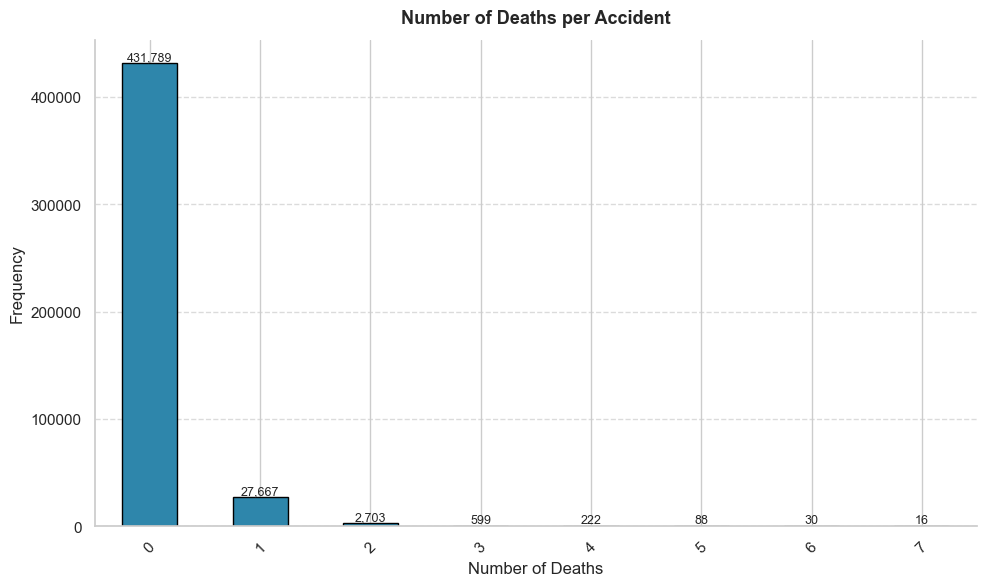

In [10]:
# Plot
plt.figure(figsize=(10, 6))
deaths_top = df['Deaths'].value_counts().sort_index().head(8)
bars = deaths_top.plot(kind='bar', color=PALETTE['primary'], edgecolor='black')

# Labels and title
plt.xlabel('Number of Deaths')
plt.ylabel('Frequency')
plt.title('Number of Deaths per Accident')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, (bar, v) in enumerate(zip(bars.patches, deaths_top.values)):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:,}',
             ha='center', va='bottom', fontsize=9)

# Show the plot
plt.tight_layout()
plt.show()

### 8.2 · `Ignored` distribution (Enhanced)

`Ignored` records people whose condition was not reported. Roughly 12% of accidents have at least one ignored person.

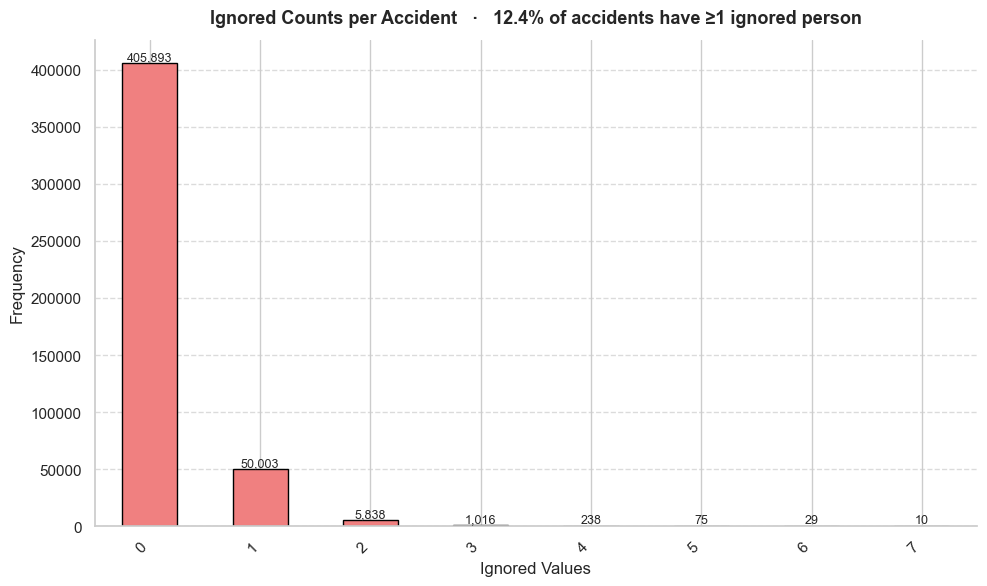

'12.4% of accidents have at least 1 ignored person'

In [11]:

# Calculate statistics
share = (df['Ignored'] > 0).mean()

# Plot
plt.figure(figsize=(10, 6))
ignored_top = df['Ignored'].value_counts().sort_index().head(8)
ignored_top.plot(kind='bar', color='lightcoral', edgecolor='black')

# Labels and title
plt.xlabel('Ignored Values')
plt.ylabel('Frequency')
plt.title(f'Ignored Counts per Accident   ·   {share:.1%} of accidents have ≥1 ignored person')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
bars = plt.gca()
for i, (bar, v) in enumerate(zip(bars.patches, ignored_top.values)):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:,}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Display the proportion
display(f"{share:.1%} of accidents have at least 1 ignored person")

### 8.3 · Logical checks

Two consistency checks:

* `Total_Injured` should equal `Slightly_Injured + Severely_Injured`.
* `People` should be ≥ `Vehicles_Involved`.

In [12]:
mismatch_total   = (df['Total_Injured'] != df['Slightly_Injured'] + df['Severely_Injured']).sum()
mismatch_people  = (df['People'] < df['Vehicles_Involved']).sum()

print(f"Total_Injured ≠ Slight + Severe : {mismatch_total}")
print(f"People < Vehicles_Involved      : {mismatch_people}")

if mismatch_total == 0 and mismatch_people == 0:
    print("\n Both checks pass => count columns are internally consistent.")

Total_Injured ≠ Slight + Severe : 0
People < Vehicles_Involved      : 0

 Both checks pass => count columns are internally consistent.


### 8.4 · Accident cause — raw distribution

The dataset uses 80+ free-text labels with a heavy long tail. Per supervisor feedback: **what is cause #1?**

In [13]:
cause_counts = df['Accident_Cause'].value_counts()
cause_share  = df['Accident_Cause'].value_counts(normalize=True)

print(f"Unique cause labels       : {df['Accident_Cause'].nunique()}")
print(f"#1 cause                  : {cause_counts.index[0]!r}")
print(f"   covers                 : {cause_share.iloc[0]:.1%} of all accidents")
print(f"Top 10 causes together    : {cause_share.head(10).sum():.1%}")

Unique cause labels       : 85
#1 cause                  : "Driver's lack of attention to conveyance"
   covers                 : 23.3% of all accidents
Top 10 causes together    : 69.5%


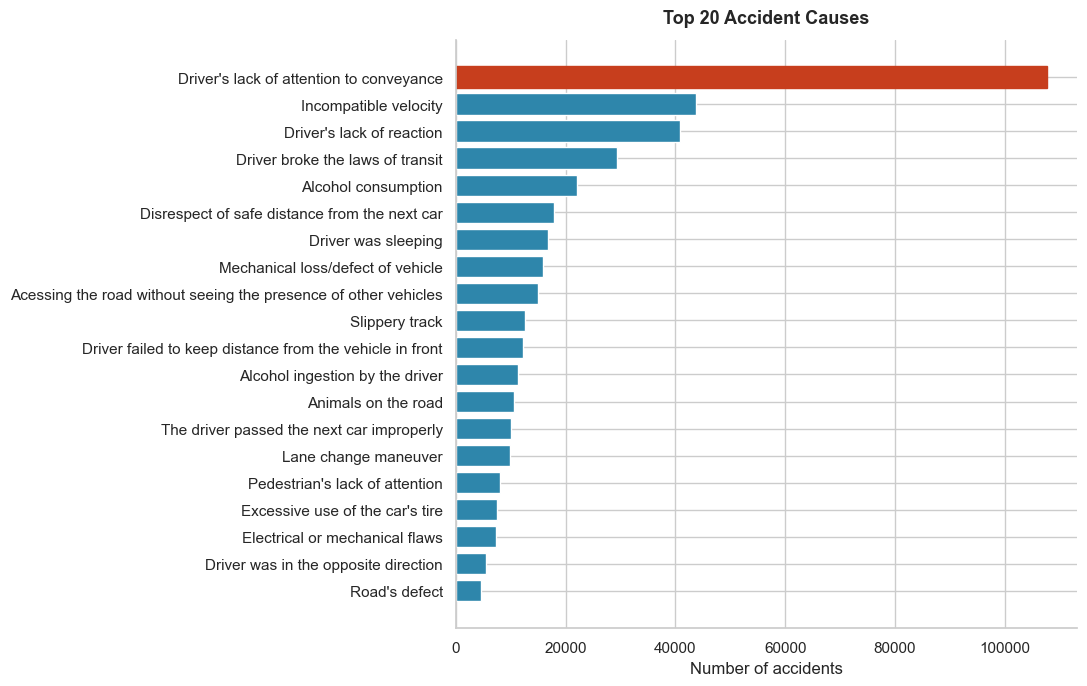

In [14]:
top20 = cause_counts.head(20)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20.index, top20.values,
               color=PALETTE['primary'], edgecolor='white')
bars[0].set_color(PALETTE['danger'])     # highlight #1
ax.invert_yaxis()
ax.set(title='Top 20 Accident Causes', xlabel='Number of accidents', ylabel='')
plt.tight_layout(); plt.show()

**Findings:** *Driver's lack of attention to conveyance* dominates. Top 10 causes cover the large majority of the dataset, therefore the next step will be to try grouping them.

### 8.5 · Combining similar causes

There are more than 80 raw tags, which isn't adequate for this model. I'm trying to group them into broader categories by comparing substrings (to capture renamed tags or nearly duplicate tags as well).

In [15]:
print(df['Accident_Cause'].value_counts().to_string())

Accident_Cause
Driver's lack of attention to conveyance                           107788
Incompatible velocity                                               43722
Driver's lack of reaction                                           40883
Driver broke the laws of transit                                    29318
Alcohol consumption                                                 22140
Disrespect of safe distance from the next car                       17929
Driver was sleeping                                                 16820
Mechanical loss/defect of vehicle                                   15850
Acessing the road without seeing the presence of other vehicles     14973
Slippery track                                                      12648
Driver failed to keep distance from the vehicle in front            12262
Alcohol ingestion by the driver                                     11229
Animals on the road                                                 10533
The driver passed the n

In [16]:
def categorise_cause(c: str) -> str:
    """Map a raw accident-cause string to a broader category."""
    if not isinstance(c, str):
        return 'Unknown'
    s = c.lower()
    # alcohol & drugs first — they often appear inside other phrases
    if 'alcohol' in s or 'drug' in s:                          return 'Alcohol / Drugs'
    if 'pedestrian' in s:                                       return 'Pedestrian-related'
    if any(k in s for k in ['sleeping', 'cardiac', 'mental',
                             'cellphone']):                     return 'Driver state (fatigue / medical / distraction)'
    if any(k in s for k in ['velocity', 'distance', 'brake']):  return 'Speed & following distance'
    if any(k in s for k in ['mechanical', 'tire', 'electrical',
                             'suspension', 'headlight',
                             'sinalization/ilumination',
                             'load', 'cargo', 'modification']): return 'Vehicle defect'
    if any(k in s for k in ['slippery','pavement','pothole','holes',
                             'sand','wreckage','oil','water','drainage',
                             'drenage','curvy','downhill','unlevel',
                             'breakdown lane','obstacle','maintenance',
                             'speed reducer','static object',
                             "road's defect","flaws/problems in the road"]):
        return 'Road condition / infrastructure'
    if any(k in s for k in ['sinalization','ilumination of the road',
                             'visibility','fog','smoke','sign post',
                             'traffic light']):                  return 'Visibility & signage'
    if 'rain' in s or 'natural phenomena' in s:                  return 'Weather'
    if 'animal' in s:                                            return 'Animals'
    if any(k in s for k in ['lack of attention','lack of reaction',
                             'broke the laws','opposite direction',
                             'lane change','passed the next car',
                             'acessing the road','intersection',
                             'conversion','red traffic light','illegally',
                             'breakdown lane','irregular access',
                             'prohibited place','drifting',
                             'temporary return','on sidewalk']):
        return 'Driver behaviour'
    return 'Other'

df['Cause_Group'] = df['Accident_Cause'].apply(categorise_cause)
df['Cause_Group'].value_counts(normalize=True).mul(100).round(1)

Cause_Group
Driver behaviour                                 49.200
Speed & following distance                       16.400
Alcohol / Drugs                                   7.800
Vehicle defect                                    7.500
Road condition / infrastructure                   6.200
Driver state (fatigue / medical / distraction)    4.700
Pedestrian-related                                3.100
Animals                                           2.300
Visibility & signage                              1.200
Weather                                           1.000
Other                                             0.800
Name: proportion, dtype: float64

**Finding.** *Driver behaviour* (inattention, illegal manoeuvres, ignored signs) is dominant, followed by *Speed & following distance* and *Alcohol / Drugs*. Environmental factors (weather, animals, visibility) are responsible for a much smaller accidents.

HERE new

### 8.6 · Contextual categorical columns


In [17]:
for col in ['Day_Phase', 'Weather_Condition', 'Road_Type', 'Road_Delineation', 'Km_Direction']:
    print(f"── {col} ──")
    print(df[col].value_counts().to_string())
    print()

── Day_Phase ──
Day_Phase
Day        253125
Night      161658
Sunset      25549
Sunrise     22801

── Weather_Condition ──
Weather_Condition
Clear sky    269949
Cloudy        78676
Rainy         54134
Sunny         32766
Drizzle       15986
Ignored        6673
Fog            3956
Windy           967
Hail             18
Snowy             8

── Road_Type ──
Road_Type
Simple      234099
Double      191619
Multiple     37415

── Road_Delineation ──
Road_Delineation
Straight             278785
Curve                 73506
Not Reported          58640
Intersection          19718
Temporary Detour      12257
Roundabout             8972
Authorized U-turn      5176
Overpass               3159
Bridge                 2395
Tunnel                  525

── Km_Direction ──
Km_Direction
Increasing      246682
Decreasing      215470
Not informed       981



### 8.7 · Time distribution

Derive time features once, then chart them. `Is_Weekend` is also derived here.

In [18]:
df['Hour']       = df['Datetime'].dt.hour
df['Month']      = df['Datetime'].dt.month
df['Weekday']    = df['Datetime'].dt.day_name()
df['Is_Weekend'] = df['Datetime'].dt.dayofweek >= 5   # Sat=5, Sun=6

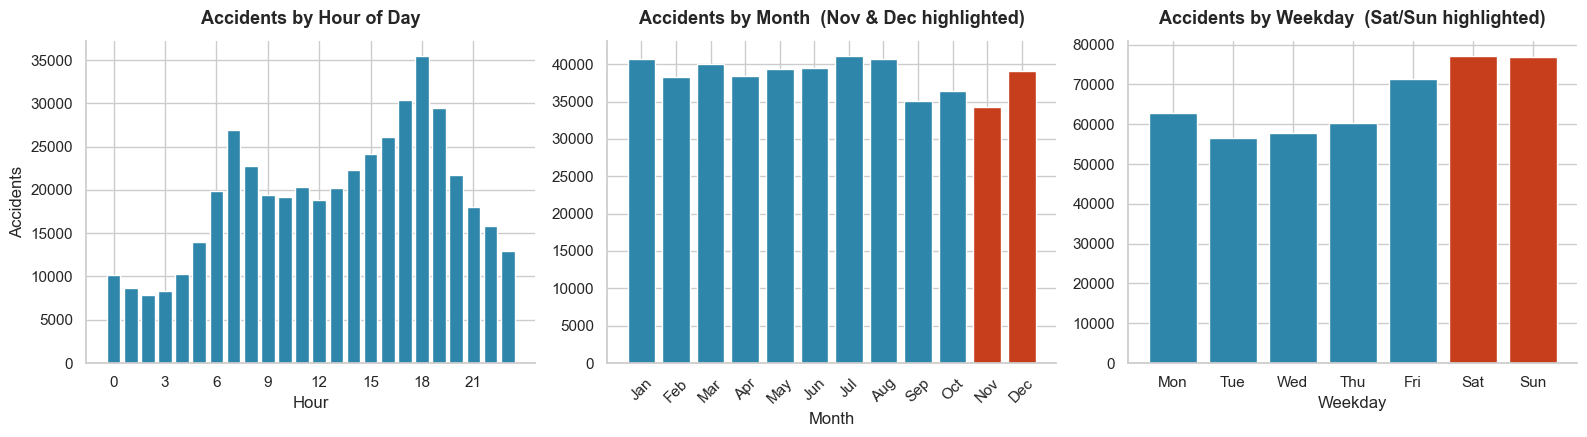

November: 34,321  ·  December: 39,122   (+14.0% Nov→Dec)


In [19]:
hourly  = df['Hour'].value_counts().sort_index()
monthly = df['Month'].value_counts().sort_index()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly  = df['Weekday'].value_counts().reindex(weekday_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Hour
axes[0].bar(hourly.index, hourly.values, color=PALETTE['primary'], edgecolor='white')
axes[0].set(title='Accidents by Hour of Day', xlabel='Hour', ylabel='Accidents')
axes[0].set_xticks(range(0, 24, 3))

# Month — highlight Nov & Dec
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_colors = [PALETTE['primary']] * 10 + [PALETTE['danger']] * 2
axes[1].bar(month_names, monthly.values, color=month_colors, edgecolor='white')
axes[1].set(title='Accidents by Month  (Nov & Dec highlighted)', xlabel='Month', ylabel='')
axes[1].tick_params(axis='x', rotation=45)

# Weekday — highlight Sat/Sun
weekday_colors = [PALETTE['primary']] * 5 + [PALETTE['danger']] * 2
axes[2].bar([d[:3] for d in weekday_order], weekly.values,
            color=weekday_colors, edgecolor='white')
axes[2].set(title='Accidents by Weekday  (Sat/Sun highlighted)', xlabel='Weekday', ylabel='')

plt.tight_layout(); plt.show()

# Nov→Dec change
nov_dec_change = (monthly[12] - monthly[11]) / monthly[11] * 100
print(f"November: {monthly[11]:,}  ·  December: {monthly[12]:,}   ({nov_dec_change:+.1f}% Nov→Dec)")

**Findings:**

* **Hour of day** - The number of cases rises from morning until 6:00–8:00 a.m., then drops slightly, only to climb back up to a peak in the late afternoon, likely during the evening rush hour between 5:00 and 7:00 p.m.,and drop again overnight.
* **November => December** — December shows a clear jump. Worth keeping `Month` as a model feature.
* **Weekday** — Saturday and Sunday are the two single highest-volume days of the week.

**Check** — does the original `Day` column agree with what we derive from `Datetime`?

In [20]:
df['Derived_Day'] = df['Datetime'].dt.day_name().str.lower()
mismatches = (df['Derived_Day'] != df['Day']).sum()
print(f"Mismatches between original Day and derived weekday: {mismatches}")

Mismatches between original Day and derived weekday: 0


### 8.8 · Working days vs Saturday / Sunday

Per supervisor feedback, compare working days (Mon–Fri) against the weekend (Sat–Sun)

In [21]:
per_day = df.groupby(df['Datetime'].dt.normalize()).size()

avg_weekday = per_day[per_day.index.dayofweek < 5].mean()
avg_weekend = per_day[per_day.index.dayofweek >= 5].mean()

# Severity by group
severity = df.groupby('Is_Weekend').agg(
    accidents                 = ('Deaths', 'size'),
    deaths_per_accident       = ('Deaths', 'mean'),
    severely_injured_per_acc  = ('Severely_Injured', 'mean'),
    fatal_share               = ('Deaths', lambda x: (x > 0).mean()),
)
severity.index = ['Working day (Mon–Fri)', 'Weekend (Sat–Sun)']
severity

,accidents,deaths_per_accident,severely_injured_per_acc,fatal_share
Working day (Mon–Fri),309043,0.072,0.244,0.062
Weekend (Sat–Sun),154090,0.094,0.292,0.080


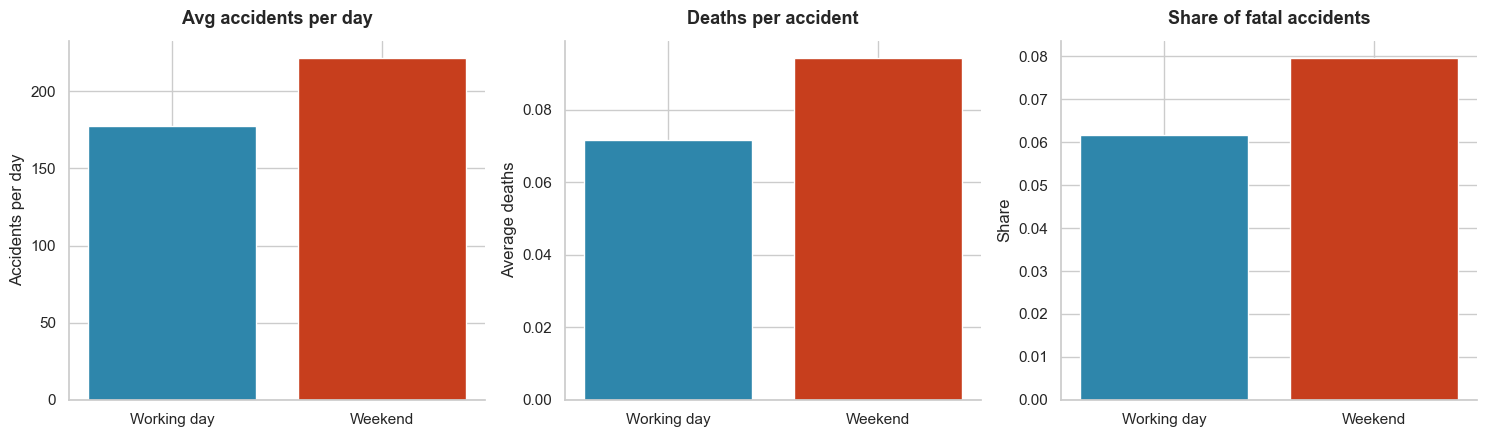

In [22]:
labels  = ['Working day', 'Weekend']
colors  = [PALETTE['primary'], PALETTE['danger']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(labels, [avg_weekday, avg_weekend], color=colors, edgecolor='white')
axes[0].set(title='Avg accidents per day', ylabel='Accidents per day')

axes[1].bar(labels, severity['deaths_per_accident'].values, color=colors, edgecolor='white')
axes[1].set(title='Deaths per accident', ylabel='Average deaths')

axes[2].bar(labels, severity['fatal_share'].values, color=colors, edgecolor='white')
axes[2].set(title='Share of fatal accidents', ylabel='Share')

plt.tight_layout(); plt.show()

**Finding.** Weekends are both *more frequent* **and** *more severe*. The combination justifies keeping `Is_Weekend` as a feature.

In [41]:
# Per-weekday volumes and severity 
per_weekday = df.groupby('Weekday').agg(
    total_accidents    = ('Deaths', 'size'),
    total_deaths       = ('Deaths', 'sum'),
    avg_deaths         = ('Deaths', 'mean'),
    fatal_share        = ('Deaths', lambda x: (x > 0).mean()),
).reindex(weekday_order)

print(per_weekday.round(4).to_string())

# How many actual Saturdays/Sundays vs weekdays in the dataset?
day_counts = df.groupby(df['Datetime'].dt.normalize().rename('day')).first().reset_index()
day_counts['dow'] = day_counts['day'].dt.day_name()
calendar_days = day_counts['dow'].value_counts().reindex(weekday_order)
print('\nCalendar days observed per weekday:')
print(calendar_days.to_string())

           total_accidents  total_deaths  avg_deaths  fatal_share
Weekday                                                          
Monday               62805          4658       0.074        0.064
Tuesday              56592          3892       0.069        0.059
Wednesday            57863          3974       0.069        0.059
Thursday             60320          4325       0.072        0.062
Friday               71429          5320       0.074        0.064
Saturday             77129          6836       0.089        0.075
Sunday               76945          7693       0.100        0.084

Calendar days observed per weekday:
dow
Monday       348
Tuesday      348
Wednesday    348
Thursday     348
Friday       347
Saturday     347
Sunday       348


The results show that, in terms of the volume of data in the dataset, Saturdays and Sundays are no different from other days. Another point I must mention is that Sundays are much more dangerous than Saturdays. From this, I conclude that I must analyze this information and take the necessary measures to address this issue.

8.8.1

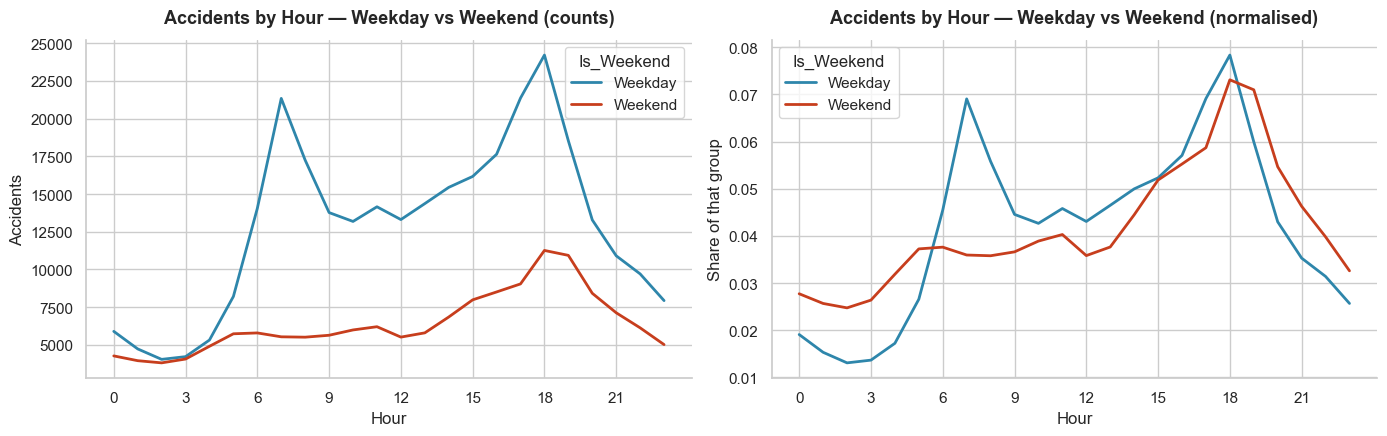

In [ ]:
# Hour of day pattern, split by weekend vs weekday
hourly_split = (df.groupby(['Is_Weekend', 'Hour'])
                  .size()
                  .unstack(level=0)
                  .rename(columns={False: 'Weekday', True: 'Weekend'}))

# Normalise so the shapes are comparable (weekdays have around 5 times more days)
hourly_split_norm = hourly_split.div(hourly_split.sum(axis=0), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Raw counts
hourly_split.plot(ax=axes[0], color=[PALETTE['primary'], PALETTE['danger']], linewidth=2)
axes[0].set(title='Accidents by Hour — Weekday vs Weekend (counts)',
            xlabel='Hour', ylabel='Accidents')
axes[0].set_xticks(range(0, 24, 3))

# Normalised, whihc should show the "shape" difference
hourly_split_norm.plot(ax=axes[1], color=[PALETTE['primary'], PALETTE['danger']], linewidth=2)
axes[1].set(title='Accidents by Hour — Weekday vs Weekend (normalised)',
            xlabel='Hour', ylabel='Share of that group')
axes[1].set_xticks(range(0, 24, 3))

plt.tight_layout(); plt.show()

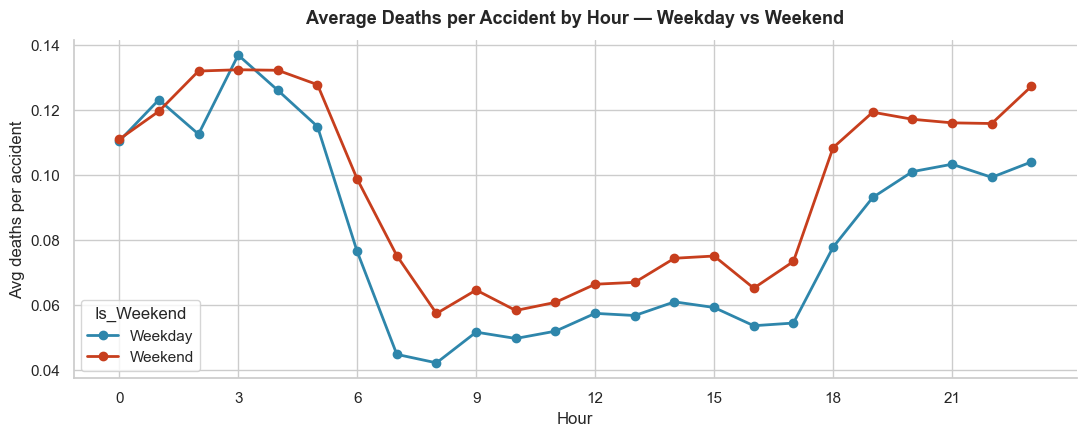

In [43]:
# Severity by hour, split by weekend
hourly_severity = (df.groupby(['Is_Weekend', 'Hour'])['Deaths']
                     .mean()
                     .unstack(level=0)
                     .rename(columns={False: 'Weekday', True: 'Weekend'}))

fig, ax = plt.subplots(figsize=(11, 4.5))
hourly_severity.plot(ax=ax, color=[PALETTE['primary'], PALETTE['danger']], linewidth=2, marker='o')
ax.set(title='Average Deaths per Accident by Hour — Weekday vs Weekend',
       xlabel='Hour', ylabel='Avg deaths per accident')
ax.set_xticks(range(0, 24, 3))
plt.tight_layout(); plt.show()

These results show that the most serious accidents occur during the night, between 6:00 p.m. and 5:00 a.m. It appears that the number of fatalities is two to three times higher during these hours, regardless of the day of the week.

In [50]:
severity = df.groupby('Day_Type').agg(
    accidents                 = ('Deaths', 'size'),
    deaths_per_accident       = ('Deaths', 'mean'),
    severely_injured_per_acc  = ('Severely_Injured', 'mean'),
    fatal_share               = ('Deaths', lambda x: (x > 0).mean()),
).reindex(['Weekday', 'Saturday', 'Sunday'])
severity

,accidents,deaths_per_accident,severely_injured_per_acc,fatal_share
Day_Type,,,,
Weekday,309009,0.072,0.243,0.062
Saturday,77129,0.089,0.285,0.075
Sunday,76945,0.100,0.299,0.084


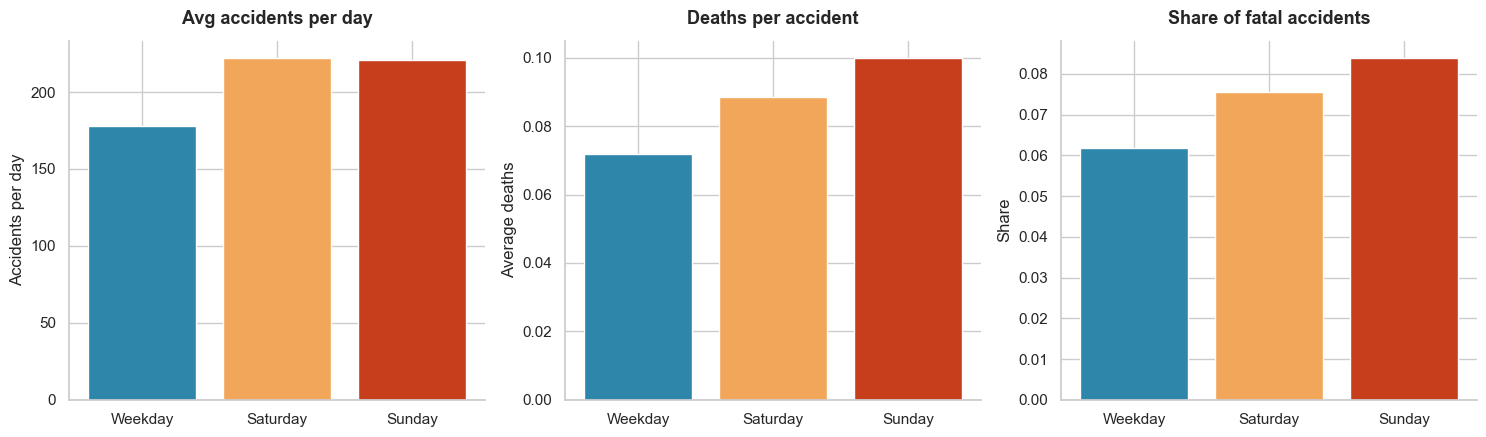

In [51]:
labels  = ['Weekday', 'Saturday', 'Sunday']
colors  = [PALETTE['primary'], PALETTE['warn'], PALETTE['danger']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Avg accidents per calendar day of that type
per_day = df.groupby(df['Datetime'].dt.normalize()).size()
day_of_week = per_day.index.dayofweek
avg_per_daytype = [
    per_day[day_of_week < 5].mean(),
    per_day[day_of_week == 5].mean(),
    per_day[day_of_week == 6].mean(),
]
axes[0].bar(labels, avg_per_daytype, color=colors, edgecolor='white')
axes[0].set(title='Avg accidents per day', ylabel='Accidents per day')

axes[1].bar(labels, severity['deaths_per_accident'].values, color=colors, edgecolor='white')
axes[1].set(title='Deaths per accident', ylabel='Average deaths')

axes[2].bar(labels, severity['fatal_share'].values, color=colors, edgecolor='white')
axes[2].set(title='Share of fatal accidents', ylabel='Share')

plt.tight_layout(); plt.show()

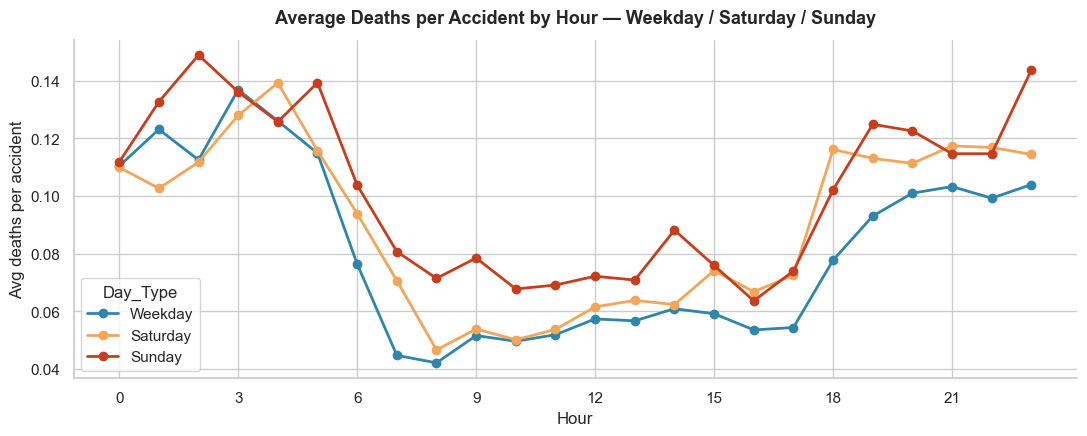

In [52]:
hourly_by_daytype = (df.groupby(['Day_Type', 'Hour'])['Deaths']
                       .mean()
                       .unstack(level=0)
                       [['Weekday', 'Saturday', 'Sunday']])

fig, ax = plt.subplots(figsize=(11, 4.5))
hourly_by_daytype.plot(ax=ax, linewidth=2, marker='o',
                       color=[PALETTE['primary'], PALETTE['warn'], PALETTE['danger']])
ax.set(title='Average Deaths per Accident by Hour — Weekday / Saturday / Sunday',
       xlabel='Hour', ylabel='Avg deaths per accident')
ax.set_xticks(range(0, 24, 3))
plt.tight_layout(); plt.show()

### 8.9 · Victims condition  (target variable)

In [23]:
victim_counts = df['Victims_Condition'].value_counts()
victim_share  = df['Victims_Condition'].value_counts(normalize=True)

summary = pd.DataFrame({'count': victim_counts, 'share': victim_share})
print(summary.to_string())

print('\nDeaths per accident by class:')
print(df.groupby('Victims_Condition')['Deaths'].mean().sort_values().to_string())

                       count  share
Victims_Condition                  
With injured victims  332206  0.717
Without victims        99583  0.215
With dead victims      31344  0.068

Deaths per accident by class:
Victims_Condition
With injured victims   0.000
Without victims        0.000
With dead victims      1.171


Heavy class imbalance — *with injured victims* are the most common, while fatal accidents make up the smallest group => An imbalance that will need to be addressed later.

---
## 9 · Bivariate / multivariate analysis

### 9.1 · Weather and day-phase context

In [24]:
print('Total deaths by weather:')
print(df.groupby('Weather_Condition')['Deaths'].sum().sort_values(ascending=False).to_string())
print('\nMean deaths/ignored by day phase:')
print(df.groupby('Day_Phase')[['Deaths', 'Ignored']].mean().round(4).to_string())

Total deaths by weather:
Weather_Condition
Clear sky    22405
Cloudy        6055
Rainy         3865
Sunny         1933
Drizzle       1105
Ignored        710
Fog            541
Windy           83
Hail             1
Snowy            0

Mean deaths/ignored by day phase:
           Deaths  Ignored
Day_Phase                 
Day         0.057    0.118
Night       0.110    0.180
Sunrise     0.116    0.160
Sunset      0.073    0.156


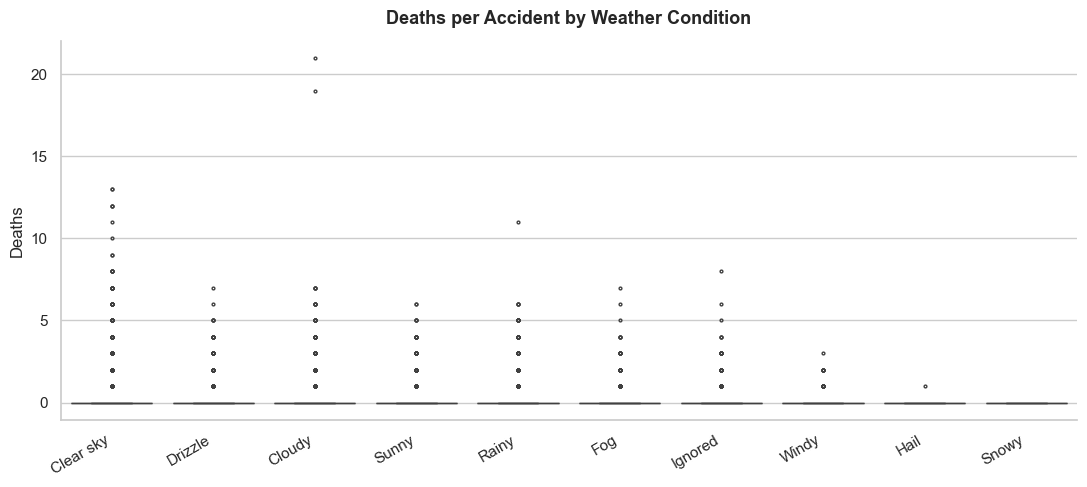

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='Weather_Condition', y='Deaths',
            color=PALETTE['primary'], ax=ax, fliersize=2)
ax.set(title='Deaths per Accident by Weather Condition', xlabel='', ylabel='Deaths')
ax.tick_params(axis='x', rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
plt.tight_layout(); plt.show()

### 9.2 · Correlation — vehicles, injuries, deaths

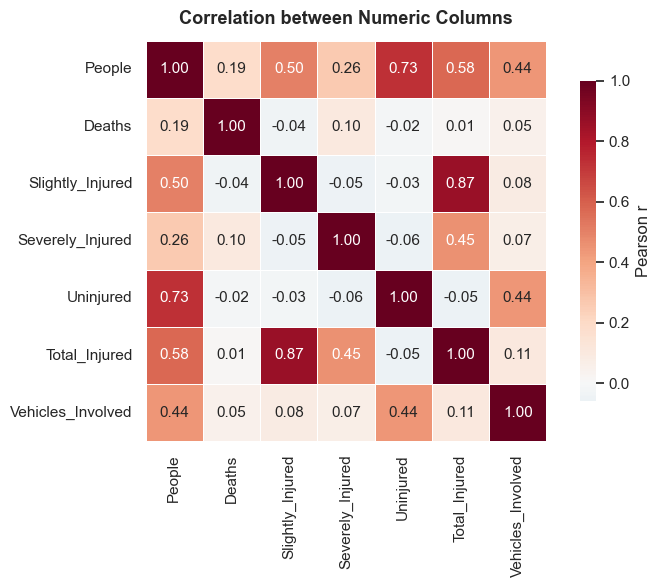

In [26]:
corr_cols = ['People','Deaths','Slightly_Injured','Severely_Injured',
             'Uninjured','Total_Injured','Vehicles_Involved']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Correlation between Numeric Columns')
plt.tight_layout(); plt.show()

### 9.3 · Road type × road delineation

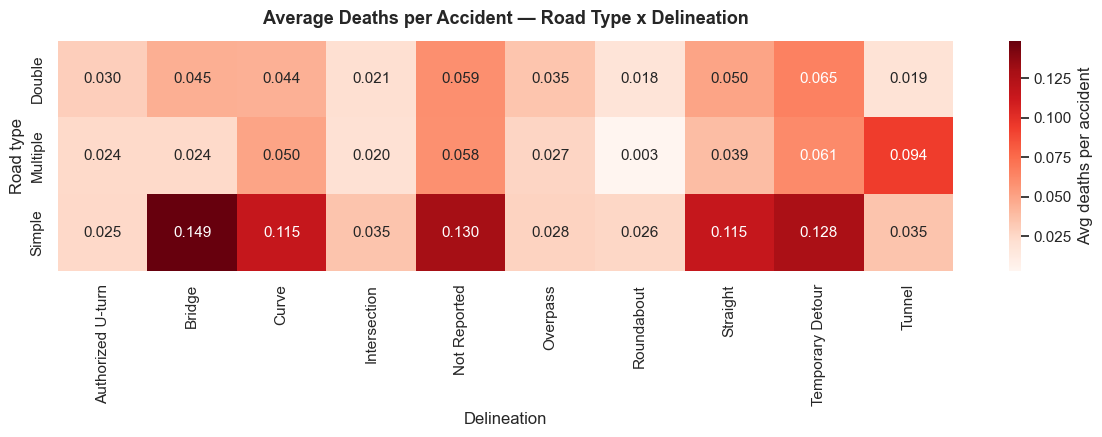

In [27]:
road_pivot = (df.groupby(['Road_Type', 'Road_Delineation'])['Deaths']
                .mean().unstack())

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(road_pivot, annot=True, fmt='.3f', cmap='Reds',
            cbar_kws={'label': 'Avg deaths per accident'}, ax=ax)
ax.set(title='Average Deaths per Accident — Road Type x Delineation',
       xlabel='Delineation', ylabel='Road type')
plt.tight_layout(); plt.show()

### 9.4 · Severity by State and Regional district

Three views, per supervisor feedback:

1. Average deaths per accident by State.
2. Severity-class mix (no-victims / injured / dead) by State.
3. Same severity mix by `Regional` district.

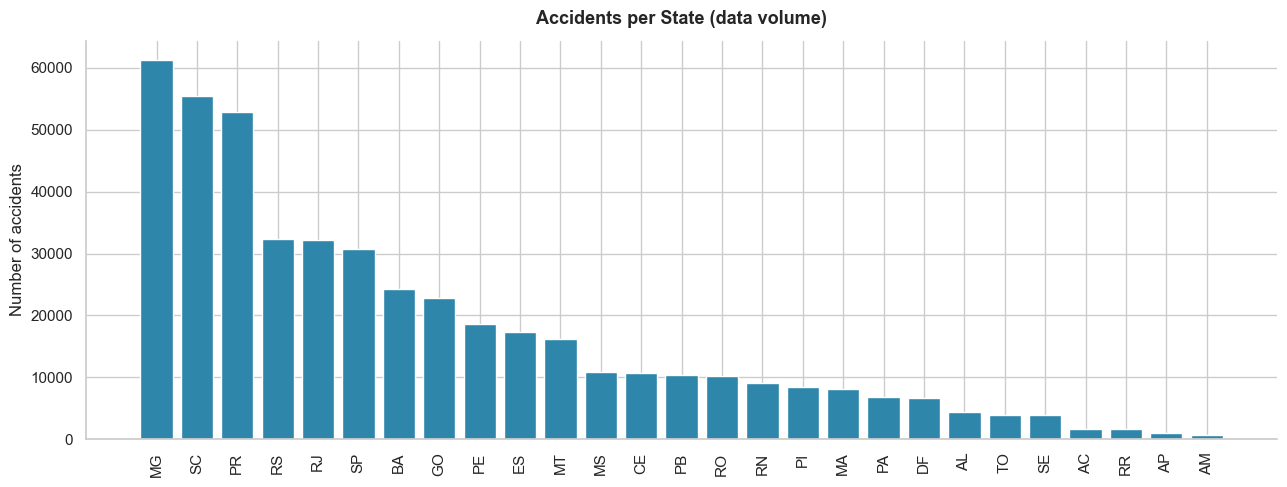

Largest state: MG (61,314 accidents)
Smallest state: AM (772 accidents)
Ratio: 79x


In [40]:
# How much data does each state contribute?
state_volume = df['State'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(state_volume.index, state_volume.values,
       color=PALETTE['primary'], edgecolor='white')
ax.set(title='Accidents per State (data volume)', ylabel='Number of accidents', xlabel='')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

print(f"Largest state: {state_volume.index[0]} ({state_volume.iloc[0]:,} accidents)")
print(f"Smallest state: {state_volume.index[-1]} ({state_volume.iloc[-1]:,} accidents)")
print(f"Ratio: {state_volume.iloc[0] / state_volume.iloc[-1]:.0f}x")

Based on this result, the dataset is significantly imbalance, not only in terms of accident types but also in terms of the proportion of data from each state. I have to address this issue or accept it and proceed.

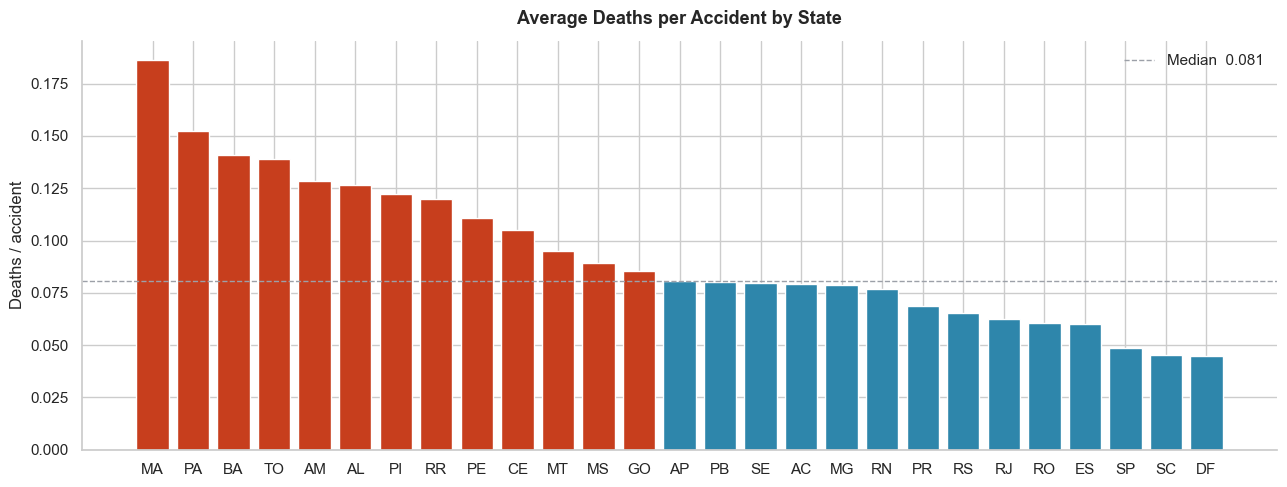

In [28]:
state_deaths = df.groupby('State')['Deaths'].mean().sort_values(ascending=False)
median = state_deaths.median()

fig, ax = plt.subplots(figsize=(13, 5))
colors = np.where(state_deaths > median, PALETTE['danger'], PALETTE['primary'])
ax.bar(state_deaths.index, state_deaths.values, color=colors, edgecolor='white')
ax.set(title='Average Deaths per Accident by State', ylabel='Deaths / accident', xlabel='')
ax.axhline(median, color=PALETTE['muted'], linestyle='--', linewidth=1,
           label=f'Median  {median:.3f}')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout(); plt.show()

In [ ]:
# Why is MA's average so high?
state_profile = df.groupby('State').agg(
    accidents          = ('Deaths', 'size'),
    avg_deaths         = ('Deaths', 'mean'),
    total_deaths       = ('Deaths', 'sum'),
    fatal_share        = ('Deaths', lambda x: (x > 0).mean()),
).sort_values('avg_deaths', ascending=False)

print(state_profile.round(4).to_string())

# Focus on MA
print('\nMA in context:')
print(state_profile.loc['MA'])
print(f"\nMA accidents as % of total: {state_profile.loc['MA','accidents'] / state_profile['accidents'].sum():.2%}")
print(f"National avg deaths/accident: {df['Deaths'].mean():.4f}")

       accidents  avg_deaths  total_deaths  fatal_share
State                                                  
MA          8049       0.186          1499        0.155
PA          6798       0.152          1035        0.132
BA         24335       0.141          3426        0.115
TO          3973       0.139           552        0.118
AM           772       0.128            99        0.113
AL          4427       0.127           561        0.110
PI          8522       0.122          1040        0.106
RR          1597       0.120           192        0.108
PE         18674       0.111          2070        0.100
CE         10726       0.105          1125        0.094
MT         16268       0.095          1547        0.077
MS         10862       0.089           968        0.073
GO         22745       0.086          1945        0.070
AP          1060       0.081            86        0.068
PB         10325       0.080           827        0.073
SE          3871       0.080           308      

Based on these findings, MA is indeed more deadly. There were “only” 8,049 accidents in this state, but that is sufficient to make the result reliable. It is clear that the proportion of fatal accidents is 15.5%, which is 3 to 4 times higher than in southern states such as SC, where this proportion is only 3.9%. As we can see, the northern states (PA, MA, TO) show higher fatality rates in this case, indicating a regional trend rather than isolated exceptions in individual states. 

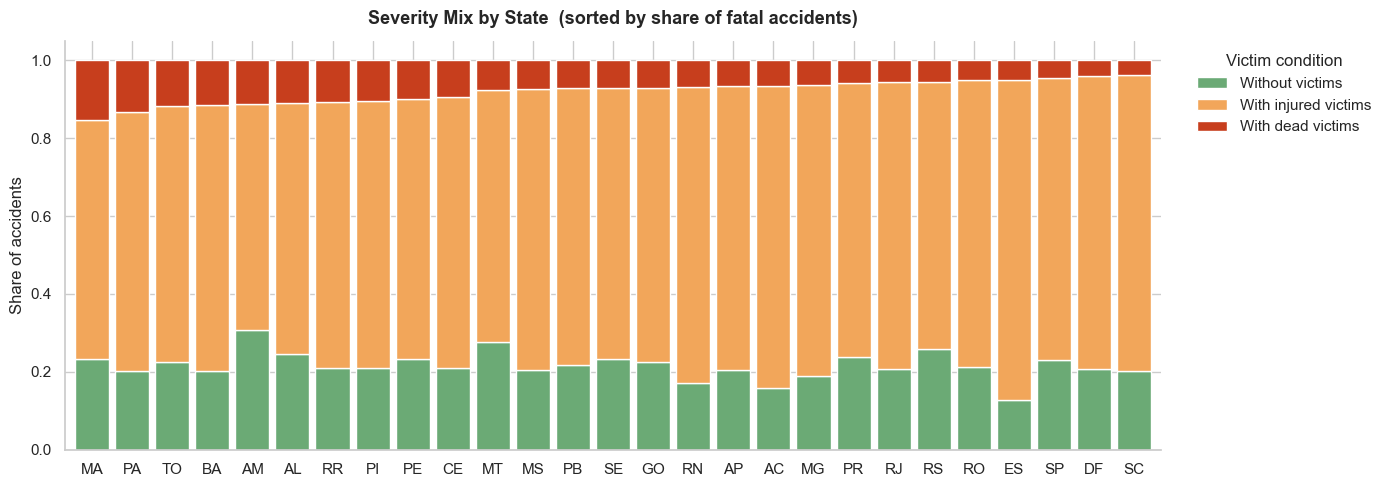

In [29]:
# Severity-class share by State, sorted by share-of-fatal
order_cols = ['Without victims', 'With injured victims', 'With dead victims']
state_severity = (df.groupby('State')['Victims_Condition']
                    .value_counts(normalize=True).unstack(fill_value=0)
                    [order_cols]
                    .sort_values('With dead victims', ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
state_severity.plot(kind='bar', stacked=True, ax=ax,
                    color=SEVERITY_COLORS, edgecolor='white', width=0.85)
ax.set(title='Severity Mix by State  (sorted by share of fatal accidents)',
       ylabel='Share of accidents', xlabel='')
ax.legend(title='Victim condition', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

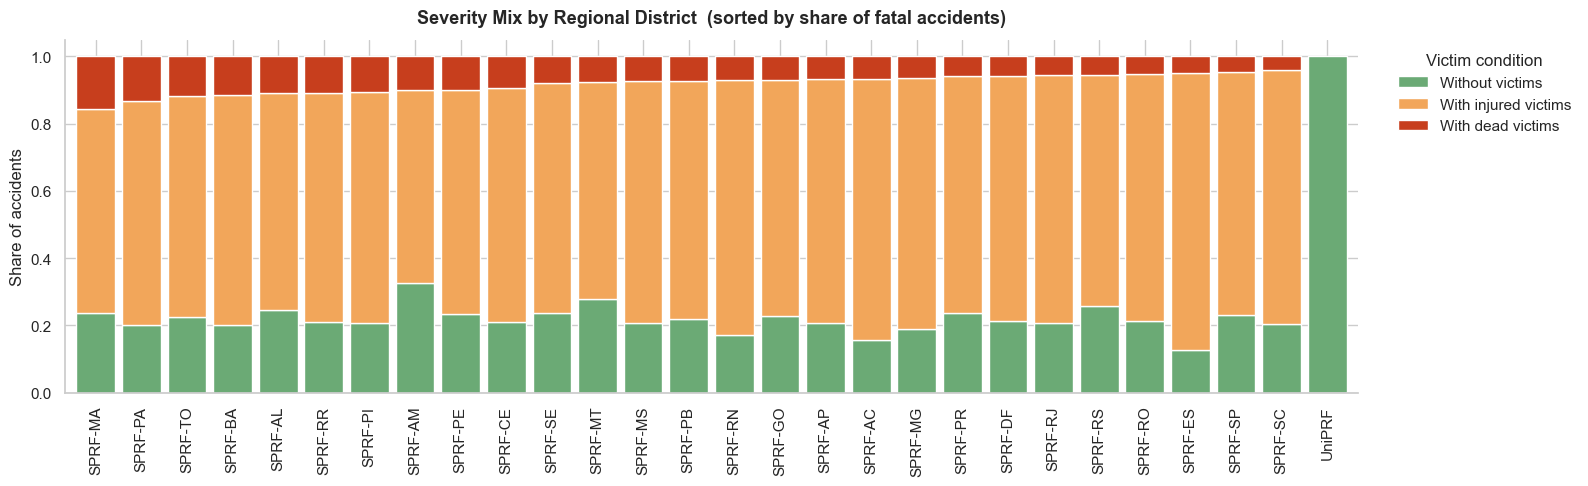

In [30]:
# Same view, by Regional
regional_severity = (df.groupby('Regional')['Victims_Condition']
                       .value_counts(normalize=True).unstack(fill_value=0)
                       [order_cols]
                       .sort_values('With dead victims', ascending=False))

fig, ax = plt.subplots(figsize=(16, 5))
regional_severity.plot(kind='bar', stacked=True, ax=ax,
                       color=SEVERITY_COLORS, edgecolor='white', width=0.85)
ax.set(title='Severity Mix by Regional District  (sorted by share of fatal accidents)',
       ylabel='Share of accidents', xlabel='')
ax.legend(title='Victim condition', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

In [31]:
print(df['Regional'].value_counts().to_string())

Regional
SPRF-MG    61177
SPRF-SC    55720
SPRF-PR    52576
SPRF-RS    32463
SPRF-RJ    32229
SPRF-SP    30694
SPRF-BA    23837
SPRF-PE    19124
SPRF-ES    17308
SPRF-MT    16196
SPRF-GO    15799
SPRF-DF    13583
SPRF-MS    10909
SPRF-CE    10757
SPRF-RO    10403
SPRF-PB    10294
SPRF-RN     9145
SPRF-PI     8711
SPRF-MA     7860
SPRF-PA     6797
SPRF-AL     4364
SPRF-SE     4128
SPRF-TO     3974
SPRF-AC     1744
SPRF-RR     1601
SPRF-AP     1067
SPRF-AM      672
UniPRF         1


???

In [32]:
(df[df['Deaths'] > 0]
   .groupby('State')['Deaths'].mean()
   .sort_values(ascending=False)
   .round(3))

State
MT   1.230
BA   1.229
MG   1.219
GO   1.217
MS   1.215
AC   1.212
MA   1.203
AP   1.194
ES   1.194
RO   1.194
RS   1.183
TO   1.179
PR   1.159
PI   1.156
PA   1.155
AL   1.152
SC   1.152
AM   1.138
RJ   1.126
PE   1.113
CE   1.111
RR   1.110
RN   1.105
SE   1.104
PB   1.101
SP   1.083
DF   1.080
Name: Deaths, dtype: float64

### 9.5 · Map of fatal accidents

In [33]:
try:
    import folium
except ImportError:
    !pip install folium -q
    import folium

m = folium.Map(location=[-15, -55], zoom_start=4, tiles='cartodbpositron')
fatal = df[df['Deaths'] > 0]
for _, r in fatal.sample(min(3000, len(fatal)), random_state=0).iterrows():
    folium.CircleMarker([r.Latitude, r.Longitude],
                        radius=2.5, color=PALETTE['danger'],
                        fill=True, fill_opacity=0.6, weight=0).add_to(m)

m.save('map.html')
m

### 9.6 · Which causes produce the deadliest accidents?

In [34]:
# Deadliest raw causes
deadliest = (df.groupby('Accident_Cause')
               .agg(count=('Deaths','count'), avg_deaths=('Deaths','mean'))
               .sort_values('avg_deaths', ascending=False)
               .head(15))
deadliest

,count,avg_deaths
Accident_Cause,,
Pedestrian was walking in the road,1780,0.438
suicide (presumed),5,0.400
Driver was in the opposite direction,5418,0.374
Disobedience to laws of transit by the pedestrian,1055,0.335
Unexpected pedestrian entry,1766,0.306
Pedestrian's lack of attention,8076,0.301
Pedestrian was crossing the road outside of the crosswalk,1583,0.255
The driver passed the next car improperly,9943,0.235
Urban area without appropriate pedestrian walking,275,0.196


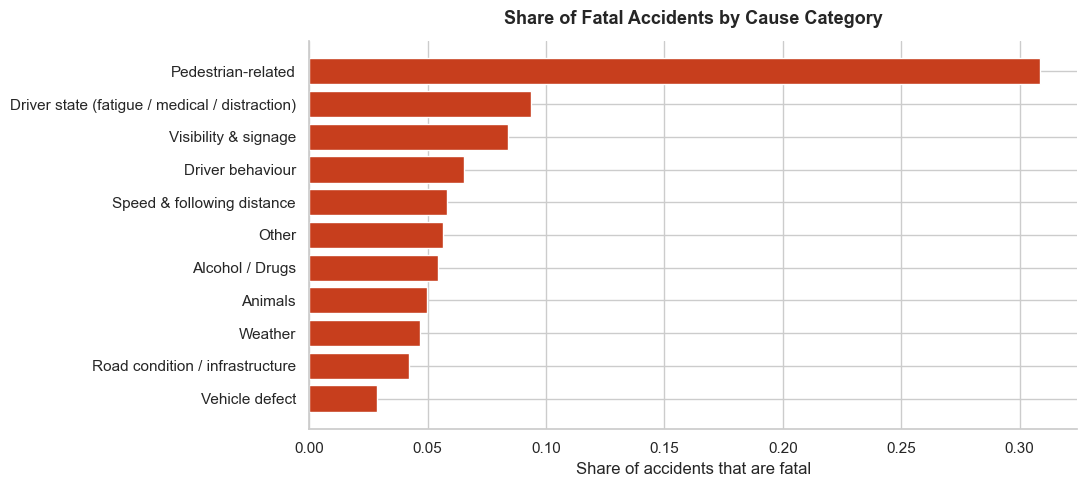

,count,avg_deaths,fatal_share
Cause_Group,,,
Pedestrian-related,14569,0.313,0.309
Driver state (fatigue / medical / distraction),21614,0.114,0.094
Visibility & signage,5372,0.095,0.084
Driver behaviour,227662,0.078,0.065
Speed & following distance,75854,0.071,0.058
Other,3800,0.059,0.056
Alcohol / Drugs,36074,0.061,0.054
Animals,10533,0.054,0.050
Weather,4525,0.058,0.047


In [35]:
# Same view at the grouped level
group_deaths = (df.groupby('Cause_Group')
                  .agg(count       = ('Deaths', 'count'),
                       avg_deaths  = ('Deaths', 'mean'),
                       fatal_share = ('Deaths', lambda x: (x > 0).mean()))
                  .sort_values('fatal_share', ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(group_deaths.index, group_deaths['fatal_share'].values,
        color=PALETTE['danger'], edgecolor='white')
ax.invert_yaxis()
ax.set(title='Share of Fatal Accidents by Cause Category',
       xlabel='Share of accidents that are fatal', ylabel='')
plt.tight_layout(); plt.show()

group_deaths.round(3)

### 9.7 · `Ignored` field exploration

In [36]:
df[['Ignored', 'Deaths', 'Uninjured', 'Vehicles_Involved']].corr().round(3)

,Ignored,Deaths,Uninjured,Vehicles_Involved
Ignored,1.000,0.081,-0.069,0.094
Deaths,0.081,1.000,-0.015,0.049
Uninjured,-0.069,-0.015,1.000,0.441
Vehicles_Involved,0.094,0.049,0.441,1.000


In [37]:
ignored_when_present = df[df['Ignored'] > 0].groupby('State')['Ignored'].mean().sort_values(ascending=False)
ignored_overall      = df.groupby('State')['Ignored'].mean().sort_values(ascending=False)

print('Avg Ignored when at least one is present (top 5):')
print(ignored_when_present.head(5).round(3).to_string())
print('\nOverall Ignored rate per State (top 5):')
print(ignored_overall.head(5).round(3).to_string())

Avg Ignored when at least one is present (top 5):
State
AM   1.436
AP   1.260
RR   1.246
RO   1.244
AC   1.239

Overall Ignored rate per State (top 5):
State
AM   0.290
PB   0.229
RR   0.219
PA   0.211
AP   0.209


---
## 10 · Outliers

IQR-based outlier counts for each numeric column, plus a coordinate check.

In [38]:
def iqr_outliers(df, col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    return df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]

count_cols = ['People','Deaths','Slightly_Injured','Severely_Injured',
              'Uninjured','Ignored','Total_Injured','Vehicles_Involved','Road_Km']

rows = [(c, len(iqr_outliers(df, c)),
         len(iqr_outliers(df, c)) / len(df)) for c in count_cols]

print(f"{'Column':<20} {'Outliers':>10}   {'Share':>7}")
print('-' * 42)
for c, n, s in rows:
    print(f"{c:<20} {n:>10,}   {s:>6.1%}")

# Coordinate sanity
invalid = df[((df['Latitude'].abs() < 0.01) | (df['Longitude'].abs() < 0.01) |
              (df['Latitude'].abs() > 90)   | (df['Longitude'].abs() > 180))]
print(f"\nInvalid / suspicious coordinates: {len(invalid):,}")

# Drop them (keep only valid coordinates)
df = df[~((df['Latitude'].abs() < 0.01) | (df['Longitude'].abs() < 0.01) |
          (df['Latitude'].abs() > 90)   | (df['Longitude'].abs() > 180))]

print(f"After dropping: {len(df):,} valid records remain")

Column                 Outliers     Share
------------------------------------------
People                    8,586     1.9%
Deaths                   31,344     6.8%
Slightly_Injured         20,283     4.4%
Severely_Injured         96,750    20.9%
Uninjured                37,195     8.0%
Ignored                  57,240    12.4%
Total_Injured            30,484     6.6%
Vehicles_Involved         8,573     1.9%
Road_Km                   4,356     0.9%

Invalid / suspicious coordinates: 50
After dropping: 463,083 valid records remain


---
## 11 · Preparing for final clean dataset

In [44]:
display(df)

,Datetime,Day,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station,Missing_Road_Data,Cause_Group,Hour,Month,Weekday,Is_Weekend,Derived_Day
0,2017-01-01 01:45:00,sunday,RS,116.000,34.900,VACARIA,Mechanical loss/defect of vehicle,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,6,0,4,0,2,0,4,2,-28.507,-50.941,SPRF-RS,DEL05-RS,False,Vehicle defect,1,1,Sunday,True,sunday
1,2017-01-01 01:00:00,sunday,PR,376.000,636.000,TIJUCAS DO SUL,Incompatible velocity,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,1,0,0,1,0,0,2,-25.754,-49.127,SPRF-PR,DEL01-PR,False,Speed & following distance,1,1,Sunday,True,sunday
2,2017-01-01 04:40:00,sunday,BA,101.000,65.000,ENTRE RIOS,Driver was sleeping,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,5,1,1,1,2,0,2,2,-11.962,-38.095,SPRF-BA,DEL01-BA,False,Driver state (fatigue / medical / distraction),4,1,Sunday,True,sunday
3,2017-01-01 06:30:00,sunday,PA,316.000,72.500,CASTANHAL,Driver's lack of attention to conveyance,Side impact collision,With dead victims,Sunrise,Decreasing,Clear sky,Simple,Straight,4,1,0,0,3,0,0,3,-1.290,-47.835,SPRF-PA,DEL01-PA,False,Driver behaviour,6,1,Sunday,True,sunday
4,2017-01-01 09:00:00,sunday,GO,20.000,220.500,POSSE,Road's defect,Collision with fixed object,With injured victims,Day,Decreasing,Clear sky,Simple,Temporary Detour,3,0,2,1,0,0,3,1,-14.142,-46.323,SPRF-DF,DEL02-DF,False,Road condition / infrastructure,9,1,Sunday,True,sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463128,2023-02-09 05:10:00,thursday,PR,116.000,89.500,PIRAQUARA,Driver's lack of reaction,Collision with object,With injured victims,Night,Increasing,Clear sky,Double,Straight,2,0,2,0,0,0,2,1,-25.454,-49.088,SPRF-PR,DEL01-PR,False,Driver behaviour,5,2,Thursday,False,thursday
463129,2023-06-28 19:48:00,wednesday,ES,101.000,271.000,SERRA,Acessing the road without seeing the presence ...,Broadside collision,With injured victims,Night,Increasing,Clear sky,Double,Straight,2,0,0,1,1,0,1,2,-20.233,-40.277,SPRF-ES,DEL02-ES,False,Driver behaviour,19,6,Wednesday,False,wednesday
463130,2023-07-27 05:20:00,thursday,PI,343.000,478.000,ANGICAL DO PIAUI,Animals on the road,Animal collision,With injured victims,Night,Decreasing,Clear sky,Simple,Curve,1,0,0,1,0,0,1,1,-6.153,-42.713,SPRF-PI,DEL01-PI,False,Animals,5,7,Thursday,False,thursday
463131,2023-05-13 09:10:00,saturday,RJ,116.000,173.000,SAO JOAO DE MERITI,Pedestrian was walking in the road,Fall of vehicle occupant,With injured victims,Day,Decreasing,Clear sky,Double,Straight,3,0,2,0,1,0,2,3,-22.798,-43.357,SPRF-RJ,DEL01-RJ,False,Pedestrian-related,9,5,Saturday,True,saturday
